# 15-bcr-influenza-epitope-databases

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import tarfile
import re
import warnings
from data.cell_type import annotate_cells
warnings.filterwarnings('ignore')

DATA = Path("data")


/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/opt/miniforge3/envs/pytcr/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
metadata = pd.read_csv(DATA / "metadata.csv", dtype={"patient": str}).set_index("patient")
metadata


,sex,age,ethnicity,race
patient,,,,
09,female,25,Not Hispanic or Latino,white
94,female,66,Not Hispanic or Latino,white


In [3]:
def extract_tar(tar_path: Path, dest: Path) -> Path:
  if not dest.exists():
    with tarfile.open(tar_path, "r:gz") as tf:
      tf.extractall(dest)
  return dest

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData]:
  cellranger_tar = next(path.glob("*_cellranger.tar.gz"))
  bcrvdj_tar = next(path.glob("*_BCRVDJ.tar.gz"))

  cellranger_dir = extract_tar(cellranger_tar, path / "cellranger")
  bcrvdj_dir = extract_tar(bcrvdj_tar, path / "BCRVDJ")
  contig_csv = next(bcrvdj_dir.glob("**/filtered_contig_annotations.csv"))

  adata_gex = sc.read_10x_mtx(cellranger_dir, var_names="gene_symbols", compressed=False)
  adata_gex.var_names_make_unique()

  adata_tcr = ir.io.read_10x_vdj(contig_csv)
  ir.pp.index_chains(adata_tcr)
  ir.tl.chain_qc(adata_tcr)

  return adata_gex, adata_tcr

def add_metadata(mdata: mu.MuData):
  cell_samples = mdata.obs_names.to_series().str.split("_", expand=True)[1]
  cell_patient = cell_samples.str.split("-", expand=True)[0]

  mdata.obs["sample"] = cell_samples
  mdata.obs["patient"] = cell_patient
  mdata.obs["days_after_vaccination"] = cell_samples.str.split("-", expand=True)[1].astype(int)
  mdata.obs["age"] = cell_patient.map(metadata["age"])
  mdata.obs["sex"] = cell_patient.map(metadata["sex"])
  mdata.obs["young"] = mdata.obs["age"] < 40
  mdata.push_obs()


In [4]:
adatas_gex = {}
adatas_tcr = {}

for sample_dir in sorted(DATA.iterdir()):
  match = re.match(r"(\d+)-(\d+)", sample_dir.name)

  if not sample_dir.is_dir() or not match:
      continue

  sample = sample_dir.name
  gex, tcr = read_sample(sample_dir)

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")

mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})
add_metadata(mdata)
mdata


MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [5]:
adata = mdata['gex']
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mdata


MuData object with n_obs × n_vars = 55114 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	49339 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	None
    airr:	46331 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical


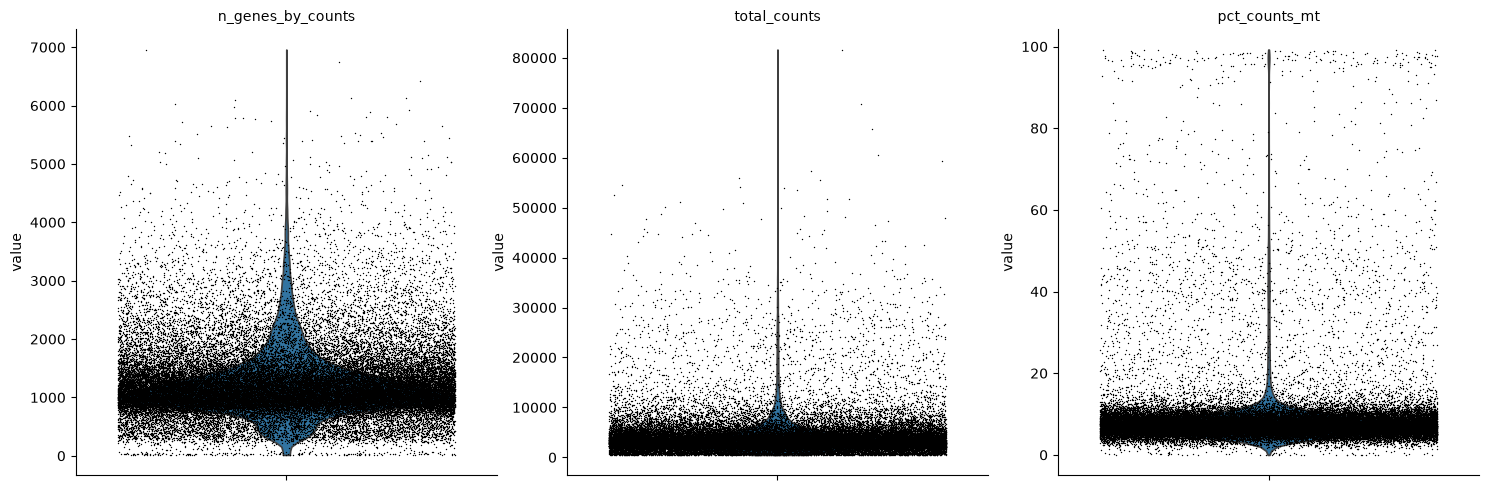

In [6]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)


In [7]:
sc.pp.filter_cells(mdata['gex'], min_genes=200)
sc.pp.filter_genes(mdata['gex'], min_cells=3)
mu.pp.filter_obs(mdata['gex'], 'pct_counts_mt', lambda x: x < 15)
mdata.update()
mu.pp.intersect_obs(mdata)


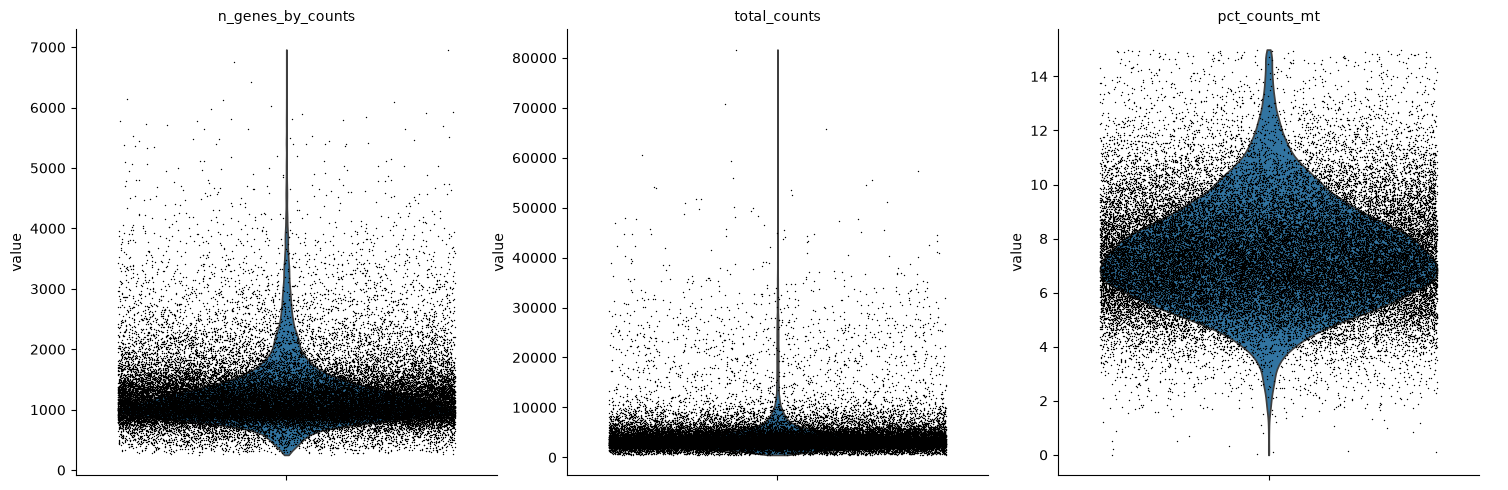

MuData object with n_obs × n_vars = 39922 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	39922 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	39922 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [8]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)
mdata


In [9]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
mdata.update()
mu.pp.intersect_obs(mdata)
mdata


MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [10]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])


In [11]:
annotate_cells(mdata)


🔬 Input data has 29101 cells and 20516 genes
🔗 Matching reference genes in the model
🧬 5645 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 29101 × 20516
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	29101 × 20516
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	29101 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

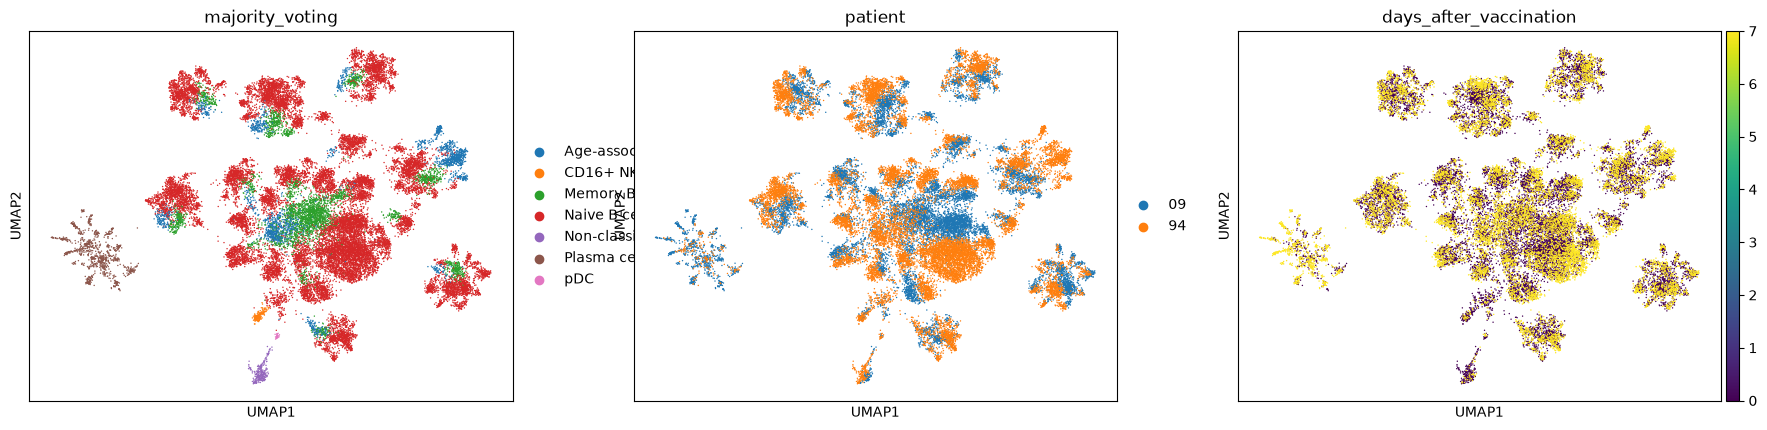

In [13]:
sc.pl.umap(
  mdata['gex'],
  color=["majority_voting", "patient", "days_after_vaccination"],
)


In [14]:
iggytop = ir.datasets.iggytop()


In [15]:
ir.pp.ir_dist(mdata, iggytop, metric="identity", sequence="aa")


In [16]:
ir.tl.ir_query(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  receptor_arms="any",
  dual_ir="any",
)

ir.tl.ir_query_annotate(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  include_ref_cols=["antigen_species"],
  strategy="most-frequent",
)

ir.tl.ir_query_annotate_df(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  include_ref_cols=["antigen_species", "antigen_name"],
)


  0%|          | 0/11325 [00:00<?, ?it/s]

,antigen_species,antigen_name
AAACCTGAGACGCAAC-1_09-0,Influenza A virus,hemagglutinin
AAACCTGAGACGCAAC-1_09-0,Homo sapiens,natalizumab
AAACCTGAGACGCAAC-1_09-0,Severe acute respiratory syndrome coronavirus 2,surface glycoprotein
AAACCTGAGAGTACCG-1_09-0,Severe acute respiratory syndrome coronavirus 2,surface glycoprotein
AAACCTGAGAGTACCG-1_09-0,Plasmodium falciparum nf54,Circumsporozoite protein
...,...,...
TTTGTCAGTTACGACT-1_94-7,Homo sapiens metapneumovirus,"fusion protein, partial"
TTTGTCAGTTCGCGAC-1_94-7,Plasmodium falciparum,Circumsporozoite protein
TTTGTCAGTTCGCGAC-1_94-7,Plasmodium falciparum,Circumsporozoite protein
TTTGTCAGTTCGCGAC-1_94-7,Plasmodium falciparum,circumsporozoite protein


... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical
... storing 'airr:antigen_species' as categorical


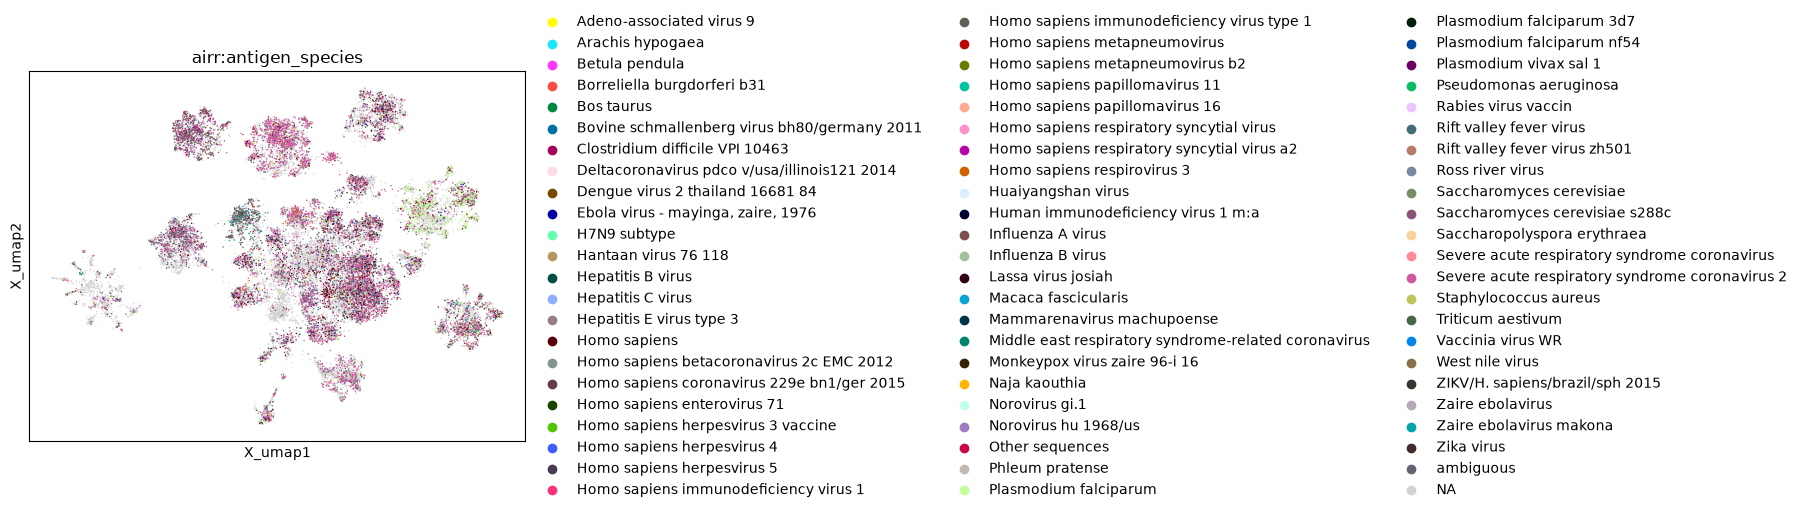

In [17]:
mu.pl.embedding(mdata, "gex:umap", color="airr:antigen_species")


... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:sex' as categorical
... storing 'airr:antigen_species' as categorical
... storing 'airr:influenza' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sex' as categorical


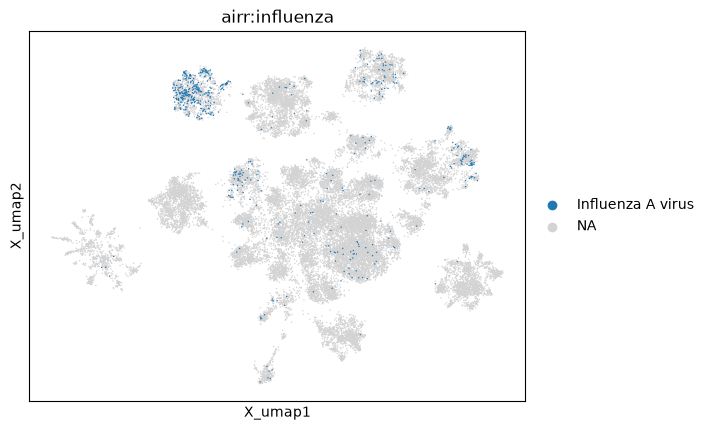

In [18]:
mask = mdata["airr"].obs["antigen_species"] == "Influenza A virus"
mdata["airr"].obs["influenza"] = mdata["airr"].obs["antigen_species"].where(mask)
mdata.update()

mu.pl.embedding(mdata, "gex:umap", color="airr:influenza", na_color="lightgrey")


In [19]:
counts = mdata['airr'].obs['antigen_species'].value_counts()
counts = counts[counts.index != "ambiguous"]
display(counts)
top_antigen_species_tumor = counts.index[0]

print(f"Most abundant antigen species: {top_antigen_species_tumor}")


antigen_species
Severe acute respiratory syndrome coronavirus 2    4682
Plasmodium falciparum                              1111
Homo sapiens                                       1011
Influenza A virus                                   589
Homo sapiens herpesvirus 5                          137
                                                   ... 
Triticum aestivum                                     1
Lassa virus josiah                                    1
Hantaan virus 76 118                                  1
Norovirus gi.1                                        1
Homo sapiens coronavirus 229e bn1/ger 2015            1
Name: count, Length: 67, dtype: int64

Most abundant antigen species: Severe acute respiratory syndrome coronavirus 2


In [20]:
df = ir.tl.ir_query_annotate_df(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  include_ref_cols=["antigen_species", "antigen_name"],
)

df[df["antigen_species"] == "Influenza A virus"].groupby("antigen_name").size().sort_values(ascending=False).head(10)


antigen_name
hemagglutinin              1393
neuraminidase               422
Hemagglutinin               227
H1 HA1/HA2                  181
Hemagglutinin precursor     168
cH5/1 HA                    148
WA11 HA                     138
HA                          117
H3 HA                       111
H1 HA                       110
dtype: int64